# Modelo Preditivo de Credit Scoring - StatsModels

#### Cenário

Produto: Crédito ao consumidor  

A empresa está acompanhando um crescimento de *inadimplência* entre seus clientes e solicita a consultoria para desenvolver uma análise com base na sua carteira atual de clientes.

Para que sejam tomadas decisões mais precisas sobre concessões de crédito, ela precisa aprimorar seu modelo de crédito.

**Desafio**: 
- **Desenvolver o modelo preditivo** mediante uso do **valor target disponível na base** de dados “Base_ScoreCredito.csv” e
- **Criar um simulador do modelo** para os analistas de créditos e gerentes de conta.

## Preparação

In [2]:
# Import bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

In [ ]:
# Import do arquivo

# Olhando o arquivo previamente vi que o separador está como vírgula, então já importei corretamente
# Dessa forma evito ter que passar vírgula para ponto e passar object para float

df = pd.read_csv(r'Base_ScoreCredito.csv', sep=';', decimal=',')
df

,id,idade,sexo,estado_civil,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
0,708082083,45,F,casado,graduacao,3,40,1,40.089665,3,0,0,1,1,778.0
1,708083283,58,M,solteiro,ensino fundam,0,44,1,66.557645,3,0,0,1,0,276.3
2,708084558,46,M,divorciado,doutorado,3,35,1,123.681821,6,0,0,1,1,401.0
3,708085458,34,F,solteiro,mestrado,0,22,1,19.715934,6,0,0,1,0,347.4
4,708086958,49,F,casado,mestrado,2,36,0,0.000000,3,1,437,1,2,476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,M,casado,mestrado,0,45,1,100.128971,4,0,0,1,0,470.0
10123,828291858,38,M,solteiro,ensino fundam,0,31,1,89.805996,6,0,0,1,1,432.0
10124,828294933,49,F,casado,graduacao,3,43,1,19.799306,3,1,252,1,1,406.0
10125,828298908,54,M,casado,ensino medio,4,48,1,194.783176,4,0,0,1,1,387.0


In [4]:
## Avaliando nulos - nenhum campo nulo a tratar
pd.DataFrame(zip(df.isnull().sum(),df.isnull().sum()/len(df)), columns=['Count', 'Proportion'], index=df.columns)

,Count,Proportion
id,0,0.0
idade,0,0.0
sexo,0,0.0
estado_civil,0,0.0
escola,0,0.0
Qte_dependentes,0,0.0
tempo_ultimoservico,0,0.0
trabalha,0,0.0
vl_salario_mil,0,0.0
reg_moradia,0,0.0


In [5]:
# Avaliando os campos e dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10127 non-null  int64  
 1   idade                10127 non-null  int64  
 2   sexo                 10127 non-null  object 
 3   estado_civil         10127 non-null  object 
 4   escola               10127 non-null  object 
 5   Qte_dependentes      10127 non-null  int64  
 6   tempo_ultimoservico  10127 non-null  int64  
 7   trabalha             10127 non-null  int64  
 8   vl_salario_mil       10127 non-null  float64
 9   reg_moradia          10127 non-null  int64  
 10  casa_propria         10127 non-null  int64  
 11  vl_imovel_em_mil     10127 non-null  int64  
 12  Qte_cartoes          10127 non-null  int64  
 13  Qte_carros           10127 non-null  int64  
 14  SCORE_CREDITO        10127 non-null  float64
dtypes: float64(2), int64(10), object(3)


In [6]:
# Avaliando as características das colunas de texto

col_obj = df.select_dtypes(include=['object']).columns.to_list()

print("Colunas de texto: ", col_obj)
print()

for col in col_obj:
    print(f"Coluna {col}: ", df[col].unique())

Colunas de texto:  ['sexo', 'estado_civil', 'escola']

Coluna sexo:  ['F' 'M']
Coluna estado_civil:  ['casado' 'solteiro' 'divorciado' 'na']
Coluna escola:  ['graduacao' 'ensino fundam' 'doutorado' 'mestrado' 'ensino medio']


In [7]:
# Coluna de sexo e estado civil podem ser tratadas com one-hot encoding
# Drop_first pra não criar multicolinearidade

df = pd.get_dummies(df, columns=['sexo', 'estado_civil'], drop_first=True)
df

,id,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,708082083,45,graduacao,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False,False
1,708083283,58,ensino fundam,0,44,1,66.557645,3,0,0,1,0,276.3,True,False,False,True
2,708084558,46,doutorado,3,35,1,123.681821,6,0,0,1,1,401.0,True,True,False,False
3,708085458,34,mestrado,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,False,True
4,708086958,49,mestrado,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,mestrado,0,45,1,100.128971,4,0,0,1,0,470.0,True,False,False,False
10123,828291858,38,ensino fundam,0,31,1,89.805996,6,0,0,1,1,432.0,True,False,False,True
10124,828294933,49,graduacao,3,43,1,19.799306,3,1,252,1,1,406.0,False,False,False,False
10125,828298908,54,ensino medio,4,48,1,194.783176,4,0,0,1,1,387.0,True,False,False,False


In [8]:
# Escola pode ser tratada como ordinal
# ensino fundam -> ensino medio -> graduacao -> mestrado -> doutorado
# Sendo assim, é possível utilizar ordinal encoding

from sklearn.preprocessing import OrdinalEncoder

escola_ordem = ['ensino fundam', 'ensino medio', 'graduacao', 'mestrado', 'doutorado']
encoder = OrdinalEncoder(categories=[escola_ordem])

df['escola'] = encoder.fit_transform(df[['escola']])

df

,id,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro
0,708082083,45,2.0,3,40,1,40.089665,3,0,0,1,1,778.0,False,False,False,False
1,708083283,58,0.0,0,44,1,66.557645,3,0,0,1,0,276.3,True,False,False,True
2,708084558,46,4.0,3,35,1,123.681821,6,0,0,1,1,401.0,True,True,False,False
3,708085458,34,3.0,0,22,1,19.715934,6,0,0,1,0,347.4,False,False,False,True
4,708086958,49,3.0,2,36,0,0.000000,3,1,437,1,2,476.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,828288333,50,3.0,0,45,1,100.128971,4,0,0,1,0,470.0,True,False,False,False
10123,828291858,38,0.0,0,31,1,89.805996,6,0,0,1,1,432.0,True,False,False,True
10124,828294933,49,2.0,3,43,1,19.799306,3,1,252,1,1,406.0,False,False,False,False
10125,828298908,54,1.0,4,48,1,194.783176,4,0,0,1,1,387.0,True,False,False,False


In [9]:
# Reobservando data types

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10127 non-null  int64  
 1   idade                    10127 non-null  int64  
 2   escola                   10127 non-null  float64
 3   Qte_dependentes          10127 non-null  int64  
 4   tempo_ultimoservico      10127 non-null  int64  
 5   trabalha                 10127 non-null  int64  
 6   vl_salario_mil           10127 non-null  float64
 7   reg_moradia              10127 non-null  int64  
 8   casa_propria             10127 non-null  int64  
 9   vl_imovel_em_mil         10127 non-null  int64  
 10  Qte_cartoes              10127 non-null  int64  
 11  Qte_carros               10127 non-null  int64  
 12  SCORE_CREDITO            10127 non-null  float64
 13  sexo_M                   10127 non-null  bool   
 14  estado_civil_divorciad

In [10]:
# Salvando e dropando o ID 
ids = df['id'].copy() 
df = df.drop(columns=['id']) 

## Análise exploratória

In [11]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,vl_imovel_em_mil,Qte_cartoes,Qte_carros,SCORE_CREDITO
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,1.53,1.55,34.13,0.91,70.21,3.78,0.35,209.00,1.08,0.62,469.50
std,8.02,1.21,1.49,8.22,0.28,55.57,1.58,0.48,378.50,0.33,0.57,133.81
min,26.00,0.00,0.00,7.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,162.00
25%,41.00,1.00,0.00,30.00,1.00,21.33,3.00,0.00,0.00,1.00,0.00,375.00
50%,46.00,1.00,1.00,34.00,1.00,66.49,4.00,0.00,0.00,1.00,1.00,449.60
75%,52.00,2.00,3.00,39.00,1.00,107.54,5.00,1.00,289.00,1.00,1.00,540.90
90%,57.00,3.00,4.00,45.00,1.00,137.70,6.00,1.00,755.00,1.00,1.00,663.31
95%,60.00,4.00,4.00,48.00,1.00,188.93,6.00,1.00,1317.70,2.00,1.00,736.00
99%,65.00,4.00,5.00,54.00,1.00,205.58,6.00,1.00,1550.74,3.00,2.00,835.59


Text(0.5, 1.0, 'Histograma SCORE_CREDITO')

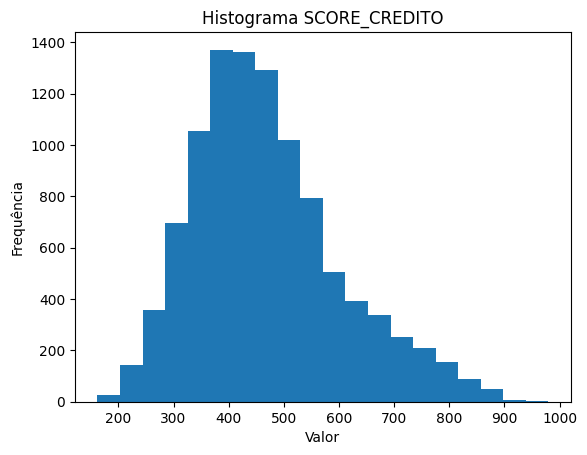

In [12]:
# Histograma da variável target/dependente - Score Crédito
target = 'SCORE_CREDITO'

plt.hist(df[target], bins=20)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title(f'Histograma {target}')

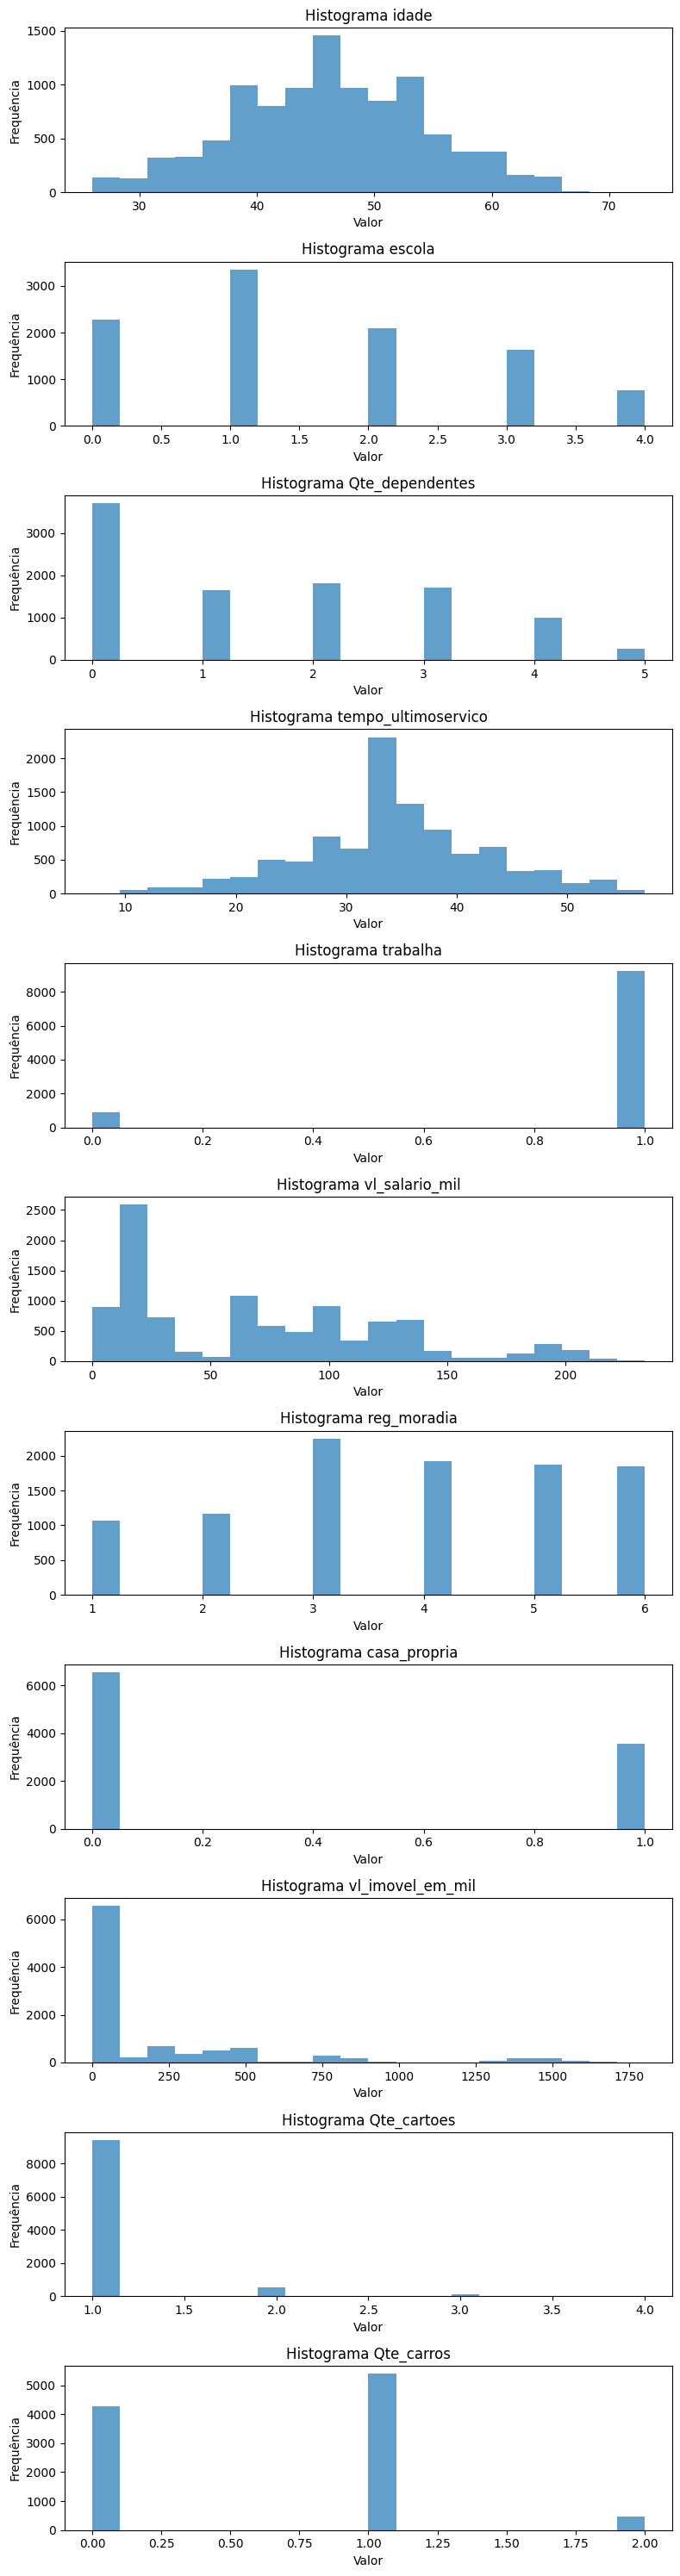

In [13]:
# Histogramas das variáveis independentes
# Avaliar distribuição

col_ind = df.select_dtypes(include=np.number).columns.to_list()
col_ind = [col for col in col_ind if col != target]

fig, axes = plt.subplots(nrows=len(col_ind), ncols=1, figsize=(8,30))
axes = axes.flatten()

for i, col in enumerate(col_ind):
    ax = axes[i] 
    ax.hist(df[col], bins=20, alpha=0.7)
    ax.set_ylabel('Frequência')
    ax.set_xlabel('Valor')
    ax.set_title(f'Histograma {col}')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, '')

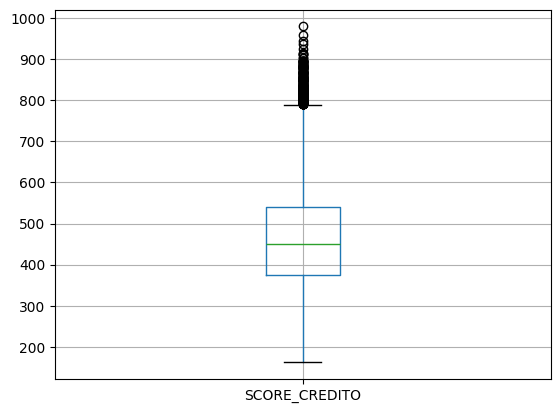

In [14]:
# Boxplot da variável dependente

fig = df.boxplot(column='SCORE_CREDITO')
fig.set_title('')

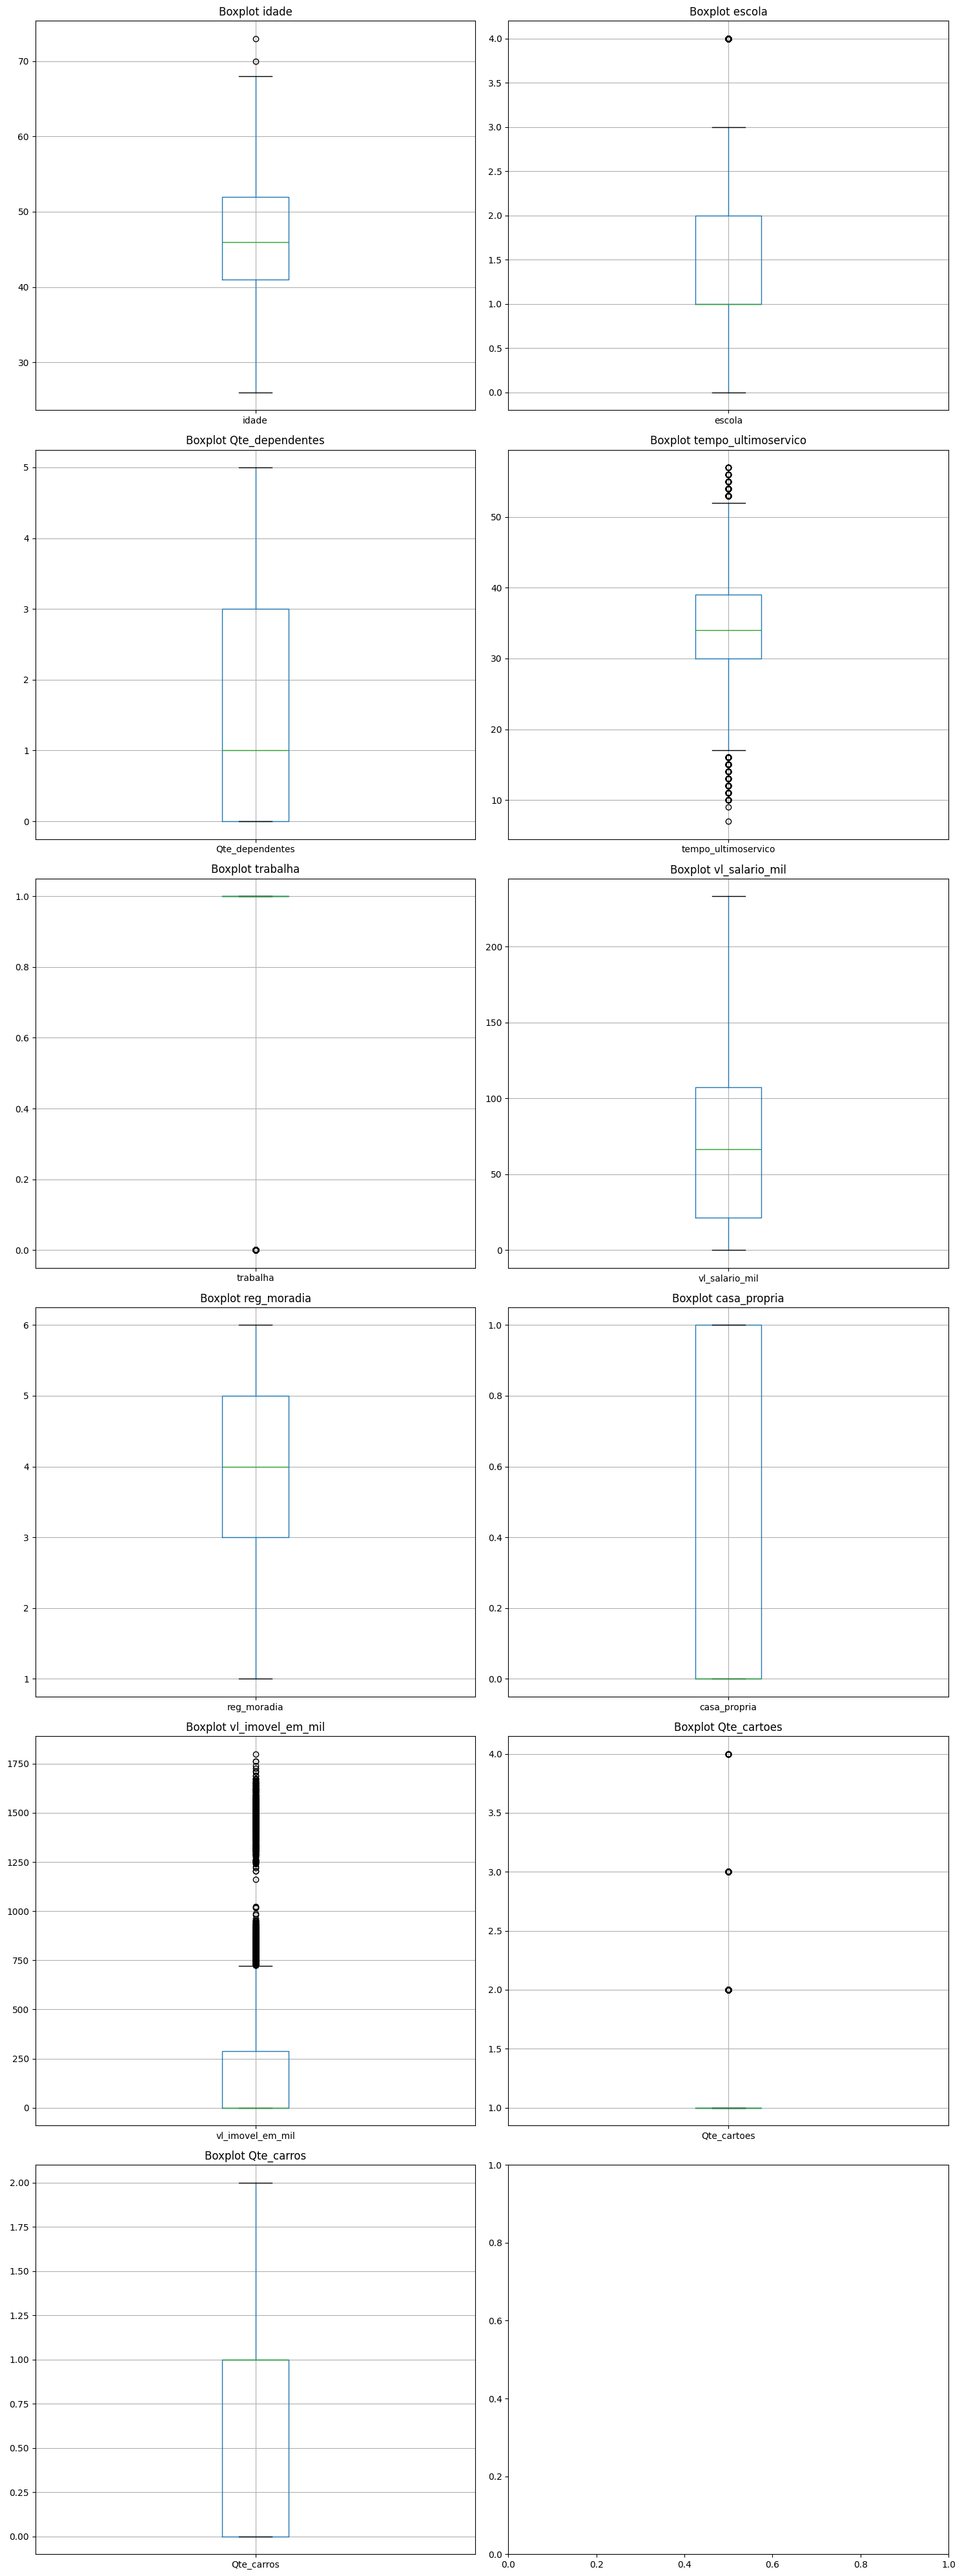

In [15]:
# Boxplot das variáveis independentes
# Avaliar outliers

col_ind = df.select_dtypes(include=np.number).columns.to_list()
col_ind = [col for col in col_ind if col != target]

fig, axes = plt.subplots(nrows=round(len(col_ind)/ 2), ncols=2, figsize=(15,40))
axes = axes.flatten()

for i, col in enumerate(col_ind):
    ax = axes[i] 
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [16]:
# Algumas variáveis apresentam pontos outliers, mas ainda mantém uma distribuição aceitável
# A variável que distoa é vl_imovel_em_mil, que tem muitos valores no 0 e alta dispersão

df['vl_imovel_em_mil'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)

count    10127.00
mean       209.00
std        378.50
min          0.00
25%          0.00
50%          0.00
75%        289.00
90%        755.00
95%       1317.70
99%       1550.74
max       1800.00
Name: vl_imovel_em_mil, dtype: float64

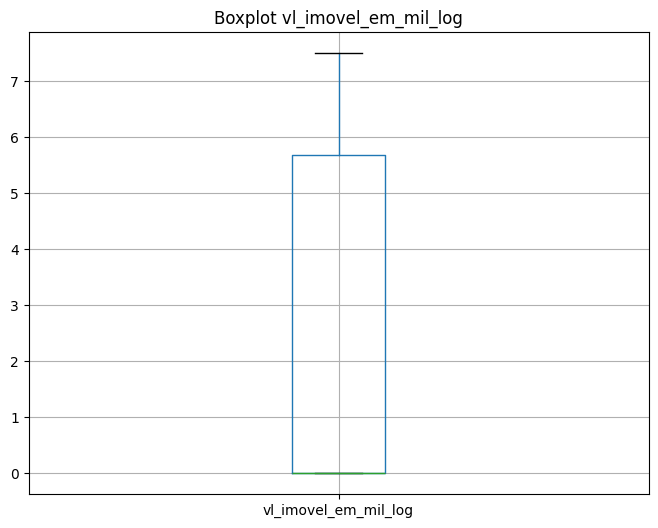

In [17]:
# Testando tratar o valor do imóvel com log1p - acentua valores máximos 
# O processo tratou os valores mais extremos, é possível dropar a coluna original

df['vl_imovel_em_mil_log'] = np.log1p(df['vl_imovel_em_mil'])

df = df.drop(columns=['vl_imovel_em_mil'])

plt.figure(figsize=(8, 6))
df.boxplot(column='vl_imovel_em_mil_log')
plt.title('Boxplot vl_imovel_em_mil_log')
plt.show()

## Correlação

In [18]:
# Reordenando a target pra facilitar a parte de correlação
cols_orig = df.columns.to_list()
cols_orig.remove('SCORE_CREDITO')
nova_ordem = cols_orig + ['SCORE_CREDITO']
df = df[nova_ordem]
df

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log,SCORE_CREDITO
0,45,2.0,3,40,1,40.089665,3,0,1,1,False,False,False,False,0.000000,778.0
1,58,0.0,0,44,1,66.557645,3,0,1,0,True,False,False,True,0.000000,276.3
2,46,4.0,3,35,1,123.681821,6,0,1,1,True,True,False,False,0.000000,401.0
3,34,3.0,0,22,1,19.715934,6,0,1,0,False,False,False,True,0.000000,347.4
4,49,3.0,2,36,0,0.000000,3,1,1,2,False,False,False,False,6.082219,476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,3.0,0,45,1,100.128971,4,0,1,0,True,False,False,False,0.000000,470.0
10123,38,0.0,0,31,1,89.805996,6,0,1,1,True,False,False,True,0.000000,432.0
10124,49,2.0,3,43,1,19.799306,3,1,1,1,False,False,False,False,5.533389,406.0
10125,54,1.0,4,48,1,194.783176,4,0,1,1,True,False,False,False,0.000000,387.0


In [19]:
# Primeira visualização de correlação entre as variáveis

df.corr().round(2)

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,casa_propria,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log,SCORE_CREDITO
idade,1.00,0.02,-0.07,0.77,0.01,0.09,-0.02,0.01,-0.02,0.05,-0.02,-0.04,-0.03,-0.01,-0.00,0.21
escola,0.02,1.00,0.01,0.05,0.03,0.24,-0.01,0.00,0.04,0.02,0.15,0.01,0.01,-0.01,0.01,0.15
Qte_dependentes,-0.07,0.01,1.00,-0.05,0.02,0.05,-0.01,0.17,-0.01,0.16,0.02,0.16,0.19,-0.71,0.16,0.10
tempo_ultimoservico,0.77,0.05,-0.05,1.00,0.03,0.13,-0.08,0.04,0.05,-0.02,0.03,-0.02,-0.02,-0.02,0.05,0.38
trabalha,0.01,0.03,0.02,0.03,1.00,0.39,-0.03,0.02,0.03,0.00,0.26,-0.01,0.01,-0.01,0.03,0.23
vl_salario_mil,0.09,0.24,0.05,0.13,0.39,1.00,-0.08,0.06,0.11,0.01,0.73,-0.01,0.01,-0.02,0.08,0.41
reg_moradia,-0.02,-0.01,-0.01,-0.08,-0.03,-0.08,1.00,-0.79,-0.12,-0.03,-0.01,0.01,-0.01,-0.01,-0.80,-0.31
casa_propria,0.01,0.00,0.17,0.04,0.02,0.06,-0.79,1.00,0.08,0.07,0.01,0.04,0.05,-0.22,0.99,0.25
Qte_cartoes,-0.02,0.04,-0.01,0.05,0.03,0.11,-0.12,0.08,1.00,-0.01,0.08,-0.00,0.02,0.04,0.10,0.31
Qte_carros,0.05,0.02,0.16,-0.02,0.00,0.01,-0.03,0.07,-0.01,1.00,-0.02,0.06,0.06,-0.23,0.07,0.25


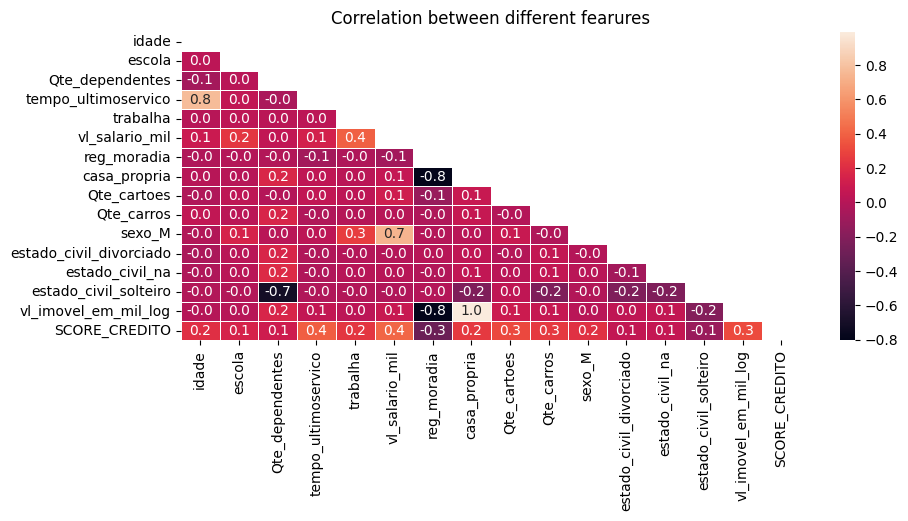

In [20]:
# Plotando a correlação em heatmap
# Atenção principal na correlação com a variável target
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
plt.figure(figsize=(10,4))
sb.heatmap(correlation, mask=mask, annot=True, fmt=".1f", linewidths=.6)
plt.title('Correlation between different fearures');

In [21]:
# Algumas variáveis independentes já mostraram alta correlação entre si
# Isso denota multicolinearidade, e pode confundir os pesos do modelo
# Pra facilitar as análises, usei duas funções:

def encontrar_correlacoes_altas(df, target_col, threshold=0.7):
    """
    Encontra e retorna pares de variáveis independentes com alta correlação.
    """
    # 1. Calcule a matriz de correlação completa
    corr_matrix = df.corr().abs()

    # 2. Remova a correlação com a variável target para focar nas independentes
    corr_matrix_ind = corr_matrix.drop(columns=target_col).drop(index=target_col)

    # 3. Crie uma máscara para o triângulo superior para evitar pares duplicados (A-B e B-A)
    mask = np.triu(np.ones_like(corr_matrix_ind, dtype=bool))
    
    # 4. Aplique a máscara e "empilhe" a matriz para criar uma lista de pares
    # O stack() transforma a matriz em uma série, facilitando a filtragem
    corr_unstacked = corr_matrix_ind.mask(mask).stack()

    # 5. Filtre para encontrar correlações acima do seu limite
    high_corr_pairs = corr_unstacked[corr_unstacked > threshold]

    # 6. Formate para um DataFrame fácil de ler
    df_high_corr = pd.DataFrame(high_corr_pairs).reset_index()
    df_high_corr.columns = ['Variavel_1', 'Variavel_2', 'Correlacao']
    
    return df_high_corr.sort_values(by='Correlacao', ascending=False)


def correlacao_com_target(df, target_col):
    """
    Calcula e retorna a correlação de todas as variáveis com a target, ordenada.
    """
    # 1. Calcule a matriz de correlação completa
    corr_matrix = df.corr()

    # 2. Selecione apenas a coluna da variável target
    corr_with_target = corr_matrix[target_col]

    # 3. Remova a correlação da target com ela mesma (que é sempre 1.0)
    corr_with_target = corr_with_target.drop(target_col)

    # 4. Ordene os valores pela correlação absoluta (módulo) para ver os mais fortes
    #    independentemente do sinal (positivo ou negativo)
    sorted_corr = corr_with_target.abs().sort_values(ascending=False)
    
    # Retorna a série original, mas na ordem da correlação absoluta
    return corr_with_target.loc[sorted_corr.index]

In [22]:
target = 'SCORE_CREDITO'
pares_independentes = encontrar_correlacoes_altas(df, target_col=target, threshold=0.5)
pares_independentes

,Variavel_1,Variavel_2,Correlacao
5,vl_imovel_em_mil_log,casa_propria,0.991127
4,vl_imovel_em_mil_log,reg_moradia,0.802694
1,casa_propria,reg_moradia,0.789461
0,tempo_ultimoservico,idade,0.768790
2,sexo_M,vl_salario_mil,0.732229
3,estado_civil_solteiro,Qte_dependentes,0.707307


In [23]:
correlacao_target = correlacao_com_target(df, target_col=target)
correlacao_target

vl_salario_mil             0.414127
tempo_ultimoservico        0.383998
vl_imovel_em_mil_log       0.316356
reg_moradia               -0.310519
Qte_cartoes                0.310481
Qte_carros                 0.253004
casa_propria               0.249615
trabalha                   0.234581
sexo_M                     0.217785
idade                      0.213320
escola                     0.148730
estado_civil_solteiro     -0.111909
Qte_dependentes            0.103554
estado_civil_na            0.064847
estado_civil_divorciado    0.053345
Name: SCORE_CREDITO, dtype: float64

In [24]:
# O trio vl_imovel_em_mil_log, reg_moradia e casa_propria apresentaram alta correlação entre si
# Tanto o valor do imóvel quanto a região da moradia informam coisas diferentes, mesmo sendo correlatos
# Por outro lado, casa_propria é somente uma flag, sua informação é repetida -> podemos descartar

# As variáveis tempo_ultimoservico e idade tem correlação esperada, mas informam coisas diferentes
# Mesma situação entre sexo_M e vl_salario_mil (tristemente), e estado_civil_solteiro e Qte_dependentes
##      Os pares não tem correlações tão diferentes entre si, quando observados com o target
##      Sendo assim, por ora resolvi mantê-los

df = df.drop(columns=['casa_propria'])

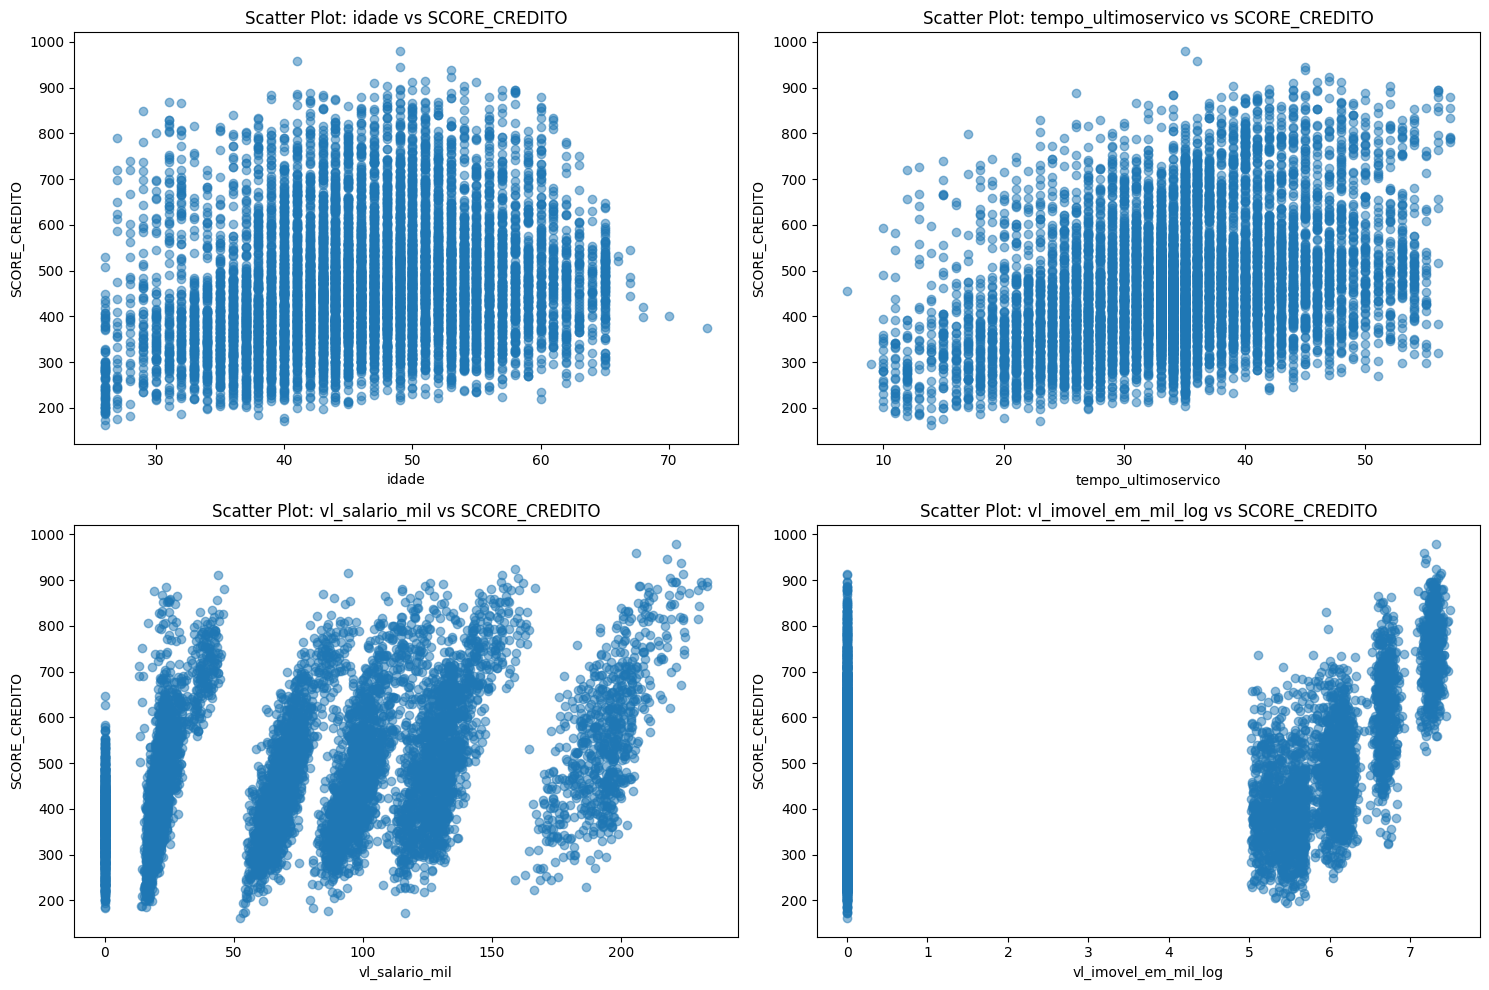

In [25]:
# Plotando scatter plots pra ver melhor a relação entre variáveis contínuas com a target

target = 'SCORE_CREDITO'
features = ['idade', 'tempo_ultimoservico', 'vl_salario_mil', 'vl_imovel_em_mil_log']

ncols = 2
nrows = (len(features) + 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.scatter(x=df[col], y=df[target], alpha=0.5)
    ax.set_ylabel(target)
    ax.set_xlabel(col)
    ax.set_title(f'Scatter Plot: {col} vs {target}')

plt.tight_layout()
plt.show()

Considerações:

A variável de maior correlação, vl_salario_mil, mostrou faixas que podem sugerir que ela não seja exatamente contínua na base
Algo parecido aconteceu com vl_imovel_em_mil_log, que também mostrou faixas
Não é algo necessariamente ruim para o modelo, mas deve ser mantido em mente, talvez valha a pena tratar como faixas, talvez não precise

Tempo_ultimoservico mostrou um pouco mais de característica linear do que idade
Vl_salario_mil, apesar de ter maior correlação, não é tão visualmente linear
Vl_imovel_em_mil_log, quando considerados os valores não zero, é razoavelmente linear visualmente

As variáveis contínuas ficaram moderadamente correlacionadas considerando Pearson

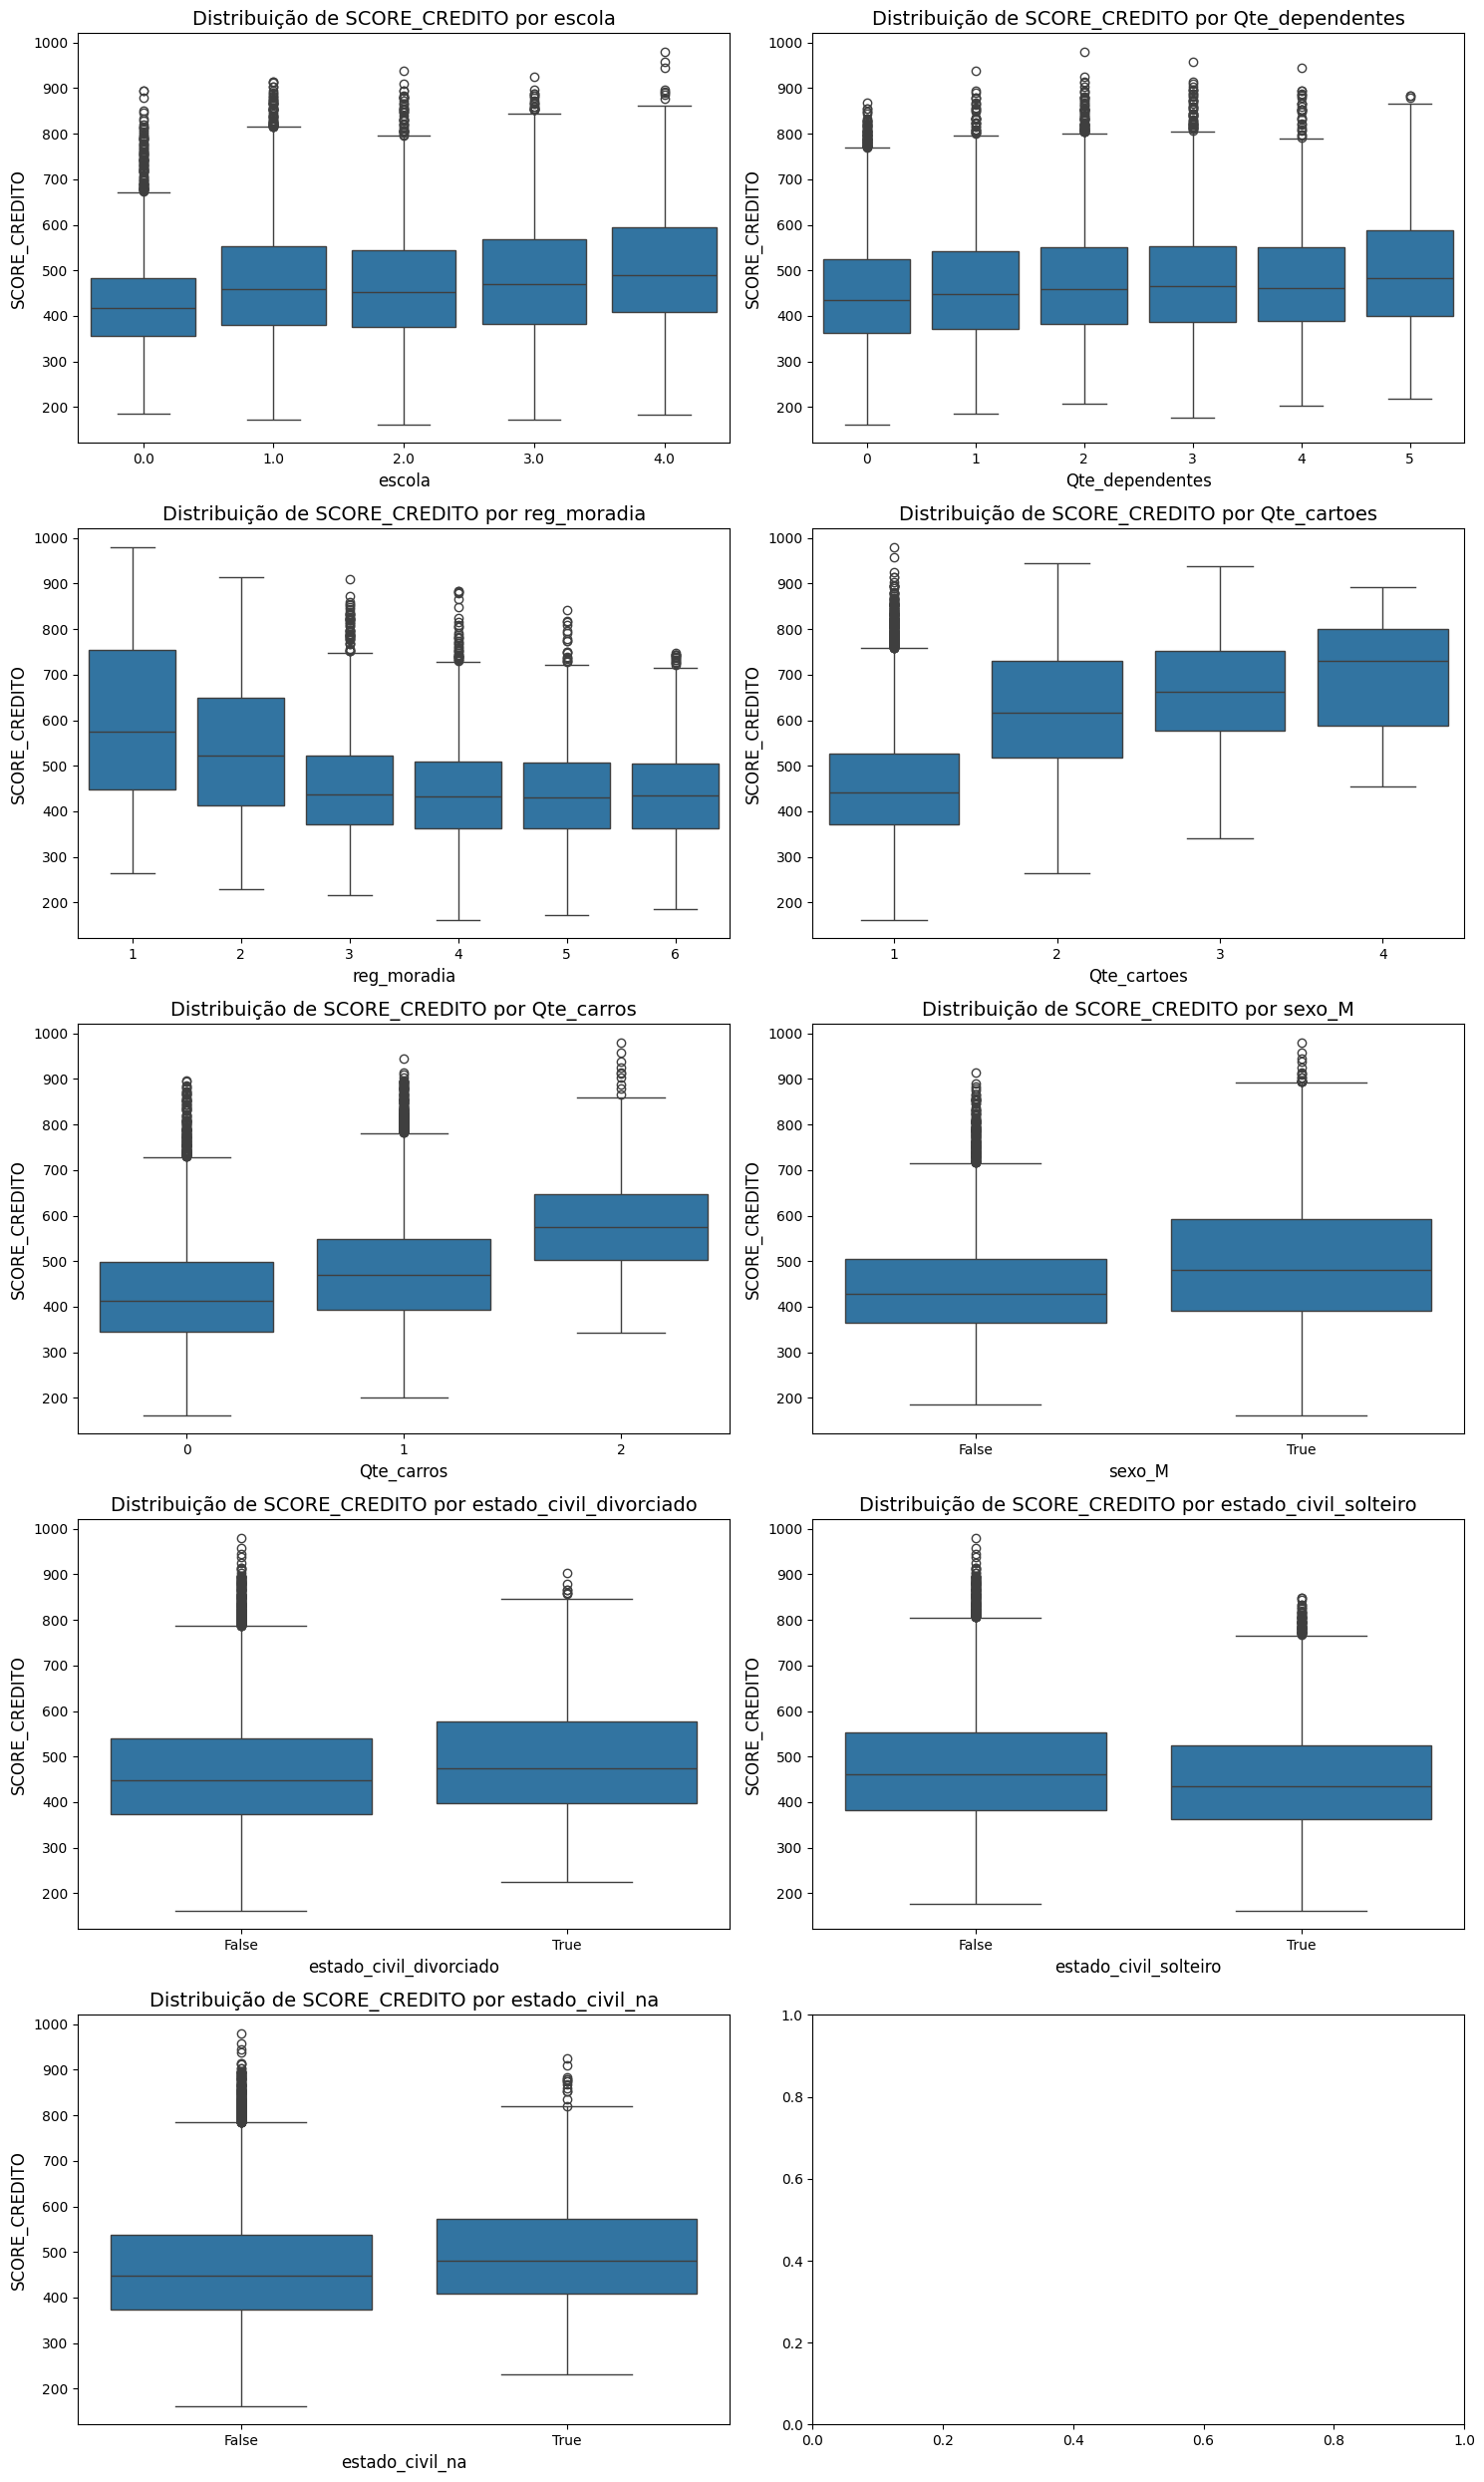

In [27]:
# Qualitativas com a target - boxplots
target = 'SCORE_CREDITO'
col_ind = ['escola', 'Qte_dependentes', 'reg_moradia', 'Qte_cartoes', 'Qte_carros', 'sexo_M', 'estado_civil_divorciado', 'estado_civil_solteiro', 'estado_civil_na']

ncols = 2
nrows = (len(col_ind) + 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(col_ind):
    ax = axes[i]
    sb.boxplot(x=col, y=target, data=df, ax=ax)
    ax.set_title(f'Distribuição de {target} por {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(target, fontsize=12)

plt.tight_layout()
plt.show()

Considerações:   
As variáveis em geral mostraram diferença entre seus valores, tendo medianas maiores/menores entre si a depender do valor em questão   
A quantidade de cartões, de carros, região da moradia e sexo aparentam maior diferença de score de crédito

In [29]:
# As variáveis qualitativas são melhores observadas por qui-quadrado do que por correlação
# Sendo assim, criarei uma categórica para a target, pra poder comparar

Q1 =  np.percentile(df['SCORE_CREDITO'], 25)
Q2 =  np.percentile(df['SCORE_CREDITO'], 50)
Q3 =  np.percentile(df['SCORE_CREDITO'], 75)
maximo = max(df['SCORE_CREDITO'])    
print(Q1, Q2, Q3, maximo)

375.0 449.6 540.9 979.65


In [30]:
df.loc[(df['SCORE_CREDITO'] >= 0) & (df['SCORE_CREDITO'] <= Q1), 'faixa_score_cred']=1.0
df.loc[(df['SCORE_CREDITO'] > Q1) & (df['SCORE_CREDITO'] <= Q2), 'faixa_score_cred']=2.0
df.loc[(df['SCORE_CREDITO']>  Q2)  & (df['SCORE_CREDITO'] <=Q3), 'faixa_score_cred']=3.0
df.loc[(df['SCORE_CREDITO'] >  Q3) & (df['SCORE_CREDITO'] <= maximo), 'faixa_score_cred']=4.0

<Axes: xlabel='faixa_score_cred', ylabel='SCORE_CREDITO'>

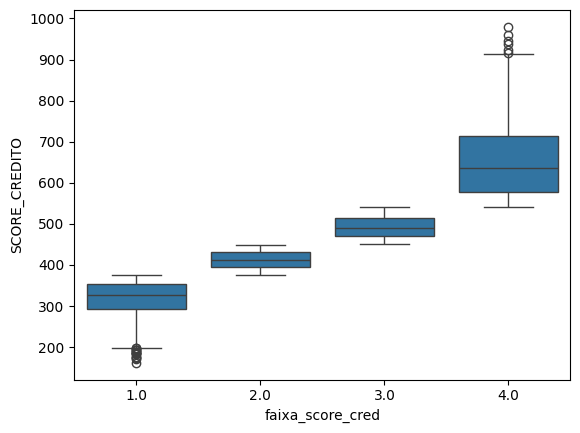

In [31]:
sb.boxplot(x='faixa_score_cred', y='SCORE_CREDITO', data=df)

In [32]:
from scipy.stats import chi2_contingency

target = 'faixa_score_cred'
col_quali = ['escola', 'Qte_dependentes', 'reg_moradia', 'Qte_cartoes', 'Qte_carros', 'sexo_M', 'estado_civil_divorciado', 'estado_civil_solteiro', 'estado_civil_na']

results = {}

for col in col_quali:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    results[col] = p_value

df_p_values = pd.DataFrame.from_dict(results, orient='index', columns=['p_valor'])
df_p_values_sorted = df_p_values.sort_values(by='p_valor', ascending=True)
df_p_values_sorted = df_p_values_sorted.round(6)
df_p_values_sorted

,p_valor
reg_moradia,0.000000
Qte_cartoes,0.000000
Qte_carros,0.000000
sexo_M,0.000000
escola,0.000000
estado_civil_solteiro,0.000000
Qte_dependentes,0.000000
estado_civil_na,0.000000
estado_civil_divorciado,0.000092


In [33]:
# Todas as variáveis categóricas apresentaram p-valor < 0.05
# Sendo assim, todas podem ser relevantes para o modelo

## 1a Modelagem - StatsModels, variáveis iniciais

In [34]:
# Descartando a variável faixa_score_cred, que não será necessária
df = df.drop(columns=['faixa_score_cred'])
df

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log,SCORE_CREDITO
0,45,2.0,3,40,1,40.089665,3,1,1,False,False,False,False,0.000000,778.0
1,58,0.0,0,44,1,66.557645,3,1,0,True,False,False,True,0.000000,276.3
2,46,4.0,3,35,1,123.681821,6,1,1,True,True,False,False,0.000000,401.0
3,34,3.0,0,22,1,19.715934,6,1,0,False,False,False,True,0.000000,347.4
4,49,3.0,2,36,0,0.000000,3,1,2,False,False,False,False,6.082219,476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,3.0,0,45,1,100.128971,4,1,0,True,False,False,False,0.000000,470.0
10123,38,0.0,0,31,1,89.805996,6,1,1,True,False,False,True,0.000000,432.0
10124,49,2.0,3,43,1,19.799306,3,1,1,False,False,False,False,5.533389,406.0
10125,54,1.0,4,48,1,194.783176,4,1,1,True,False,False,False,0.000000,387.0


In [35]:
# Separação da variável target

X = df[df.columns[:-1]]
y = df['SCORE_CREDITO']

In [36]:
X

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
0,45,2.0,3,40,1,40.089665,3,1,1,False,False,False,False,0.000000
1,58,0.0,0,44,1,66.557645,3,1,0,True,False,False,True,0.000000
2,46,4.0,3,35,1,123.681821,6,1,1,True,True,False,False,0.000000
3,34,3.0,0,22,1,19.715934,6,1,0,False,False,False,True,0.000000
4,49,3.0,2,36,0,0.000000,3,1,2,False,False,False,False,6.082219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,3.0,0,45,1,100.128971,4,1,0,True,False,False,False,0.000000
10123,38,0.0,0,31,1,89.805996,6,1,1,True,False,False,True,0.000000
10124,49,2.0,3,43,1,19.799306,3,1,1,False,False,False,False,5.533389
10125,54,1.0,4,48,1,194.783176,4,1,1,True,False,False,False,0.000000


In [37]:
y

0        778.0
1        276.3
2        401.0
3        347.4
4        476.0
         ...  
10122    470.0
10123    432.0
10124    406.0
10125    387.0
10126    513.0
Name: SCORE_CREDITO, Length: 10127, dtype: float64

In [38]:
# Separação em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 12)

In [39]:
X_train

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
5653,50,1.0,2,38,1,101.142599,4,1,0,True,False,False,False,0.000000
3391,49,0.0,3,34,1,23.173473,3,1,1,False,False,False,False,6.122493
3818,44,1.0,3,32,1,65.966874,6,1,1,True,False,False,False,0.000000
8710,30,2.0,0,17,1,20.339844,3,1,1,False,False,False,True,0.000000
8034,53,2.0,2,35,1,74.658171,1,1,2,False,False,False,False,6.218600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,49,1.0,0,38,1,79.553644,1,1,1,False,False,False,False,6.833032
7409,40,0.0,3,28,1,27.735036,1,1,0,False,False,False,False,6.754604
3325,65,2.0,0,53,1,19.924990,3,1,0,True,False,False,False,5.697093
9606,57,3.0,0,49,1,23.175998,4,1,1,False,False,False,True,0.000000


In [40]:
y_train

5653    494.0
3391    477.0
3818    494.0
8710    414.0
8034    628.0
        ...  
3714    623.0
7409    458.0
3325    530.0
9606    536.4
5787    492.3
Name: SCORE_CREDITO, Length: 7088, dtype: float64

Escolha do modelo:  
Optei por usar o statsmodels para poder observar melhor cada variável   
Se fosse só focar no resultado final, poderia usar sklearn   

In [42]:
import statsmodels.api as sm
from scipy import stats

In [43]:
# Adicionando uma constante no X_train

X_ = sm.add_constant(X_train)
X_

,const,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
5653,1.0,50,1.0,2,38,1,101.142599,4,1,0,True,False,False,False,0.000000
3391,1.0,49,0.0,3,34,1,23.173473,3,1,1,False,False,False,False,6.122493
3818,1.0,44,1.0,3,32,1,65.966874,6,1,1,True,False,False,False,0.000000
8710,1.0,30,2.0,0,17,1,20.339844,3,1,1,False,False,False,True,0.000000
8034,1.0,53,2.0,2,35,1,74.658171,1,1,2,False,False,False,False,6.218600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,1.0,49,1.0,0,38,1,79.553644,1,1,1,False,False,False,False,6.833032
7409,1.0,40,0.0,3,28,1,27.735036,1,1,0,False,False,False,False,6.754604
3325,1.0,65,2.0,0,53,1,19.924990,3,1,0,True,False,False,False,5.697093
9606,1.0,57,3.0,0,49,1,23.175998,4,1,1,False,False,False,True,0.000000


In [44]:
X_.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7088 entries, 5653 to 5787
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   const                    7088 non-null   float64
 1   idade                    7088 non-null   int64  
 2   escola                   7088 non-null   float64
 3   Qte_dependentes          7088 non-null   int64  
 4   tempo_ultimoservico      7088 non-null   int64  
 5   trabalha                 7088 non-null   int64  
 6   vl_salario_mil           7088 non-null   float64
 7   reg_moradia              7088 non-null   int64  
 8   Qte_cartoes              7088 non-null   int64  
 9   Qte_carros               7088 non-null   int64  
 10  sexo_M                   7088 non-null   bool   
 11  estado_civil_divorciado  7088 non-null   bool   
 12  estado_civil_na          7088 non-null   bool   
 13  estado_civil_solteiro    7088 non-null   bool   
 14  vl_imovel_em_mil_log     7

In [45]:
# Tive problemas de datatype na conversão pra numpy pro modelo
# Então vou forçar todas pra float64

X_ = X_.astype(float)

In [46]:
model_OLS = sm.OLS(y_train, X_).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     495.2
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:32:07   Log-Likelihood:                -42335.
No. Observations:                7088   AIC:                         8.470e+04
Df Residuals:                    7073   BIC:                         8.480e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [47]:
# Interpretação dos resultados até então:

# R²: Modelo ajustou somente 49% dos dados, pode ser baixo demais do ponto de vista de negócio
# F-statistic: Deu bem alto (495.2), modelo parece altamente significativo
# Nenhum coeficiente ficou modularmente muito alto, não parece haver multicolinearidade

In [48]:
# Confirmando multicolinearidade com VIF
# Nenhuma variável teve um VIF acima de 5, todas as multicolinearidades foram resolvidas

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)  # garante intercepto
X_vif = X_vif.astype(float)

# Calcula VIF para cada coluna
vif = pd.DataFrame()
vif["variável"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif)

                   variável         VIF
0                     const  105.583407
1                     idade    2.530251
2                    escola    1.069010
3           Qte_dependentes    2.041920
4       tempo_ultimoservico    2.535706
5                  trabalha    1.191764
6            vl_salario_mil    2.599156
7               reg_moradia    3.110986
8               Qte_cartoes    1.036547
9                Qte_carros    1.069829
10                   sexo_M    2.216047
11  estado_civil_divorciado    1.077649
12          estado_civil_na    1.078538
13    estado_civil_solteiro    2.347406
14     vl_imovel_em_mil_log    3.225694


In [49]:
# Calculando medidas de performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Aplicando 
y_train_pred = model_OLS.predict(X_)

# Avaliando
# Medidas de erro na amostra treino 

me1   = round((y_train-y_train_pred).mean(),2)
print('Erro Médio (Mean error-ME):', me1)
mae1  = round((mean_absolute_error(y_train, y_train_pred)),2)
print('Erro Médio Absoluto (Mean Absolut Error-MAE):', mae1) 
mse1  =round( (mean_squared_error(y_train, y_train_pred)),2)
print('Erro Quadrático Médio (Mean Squared Error-MSE)::', mse1) 
rmse1  = round((np.sqrt(mean_squared_error(y_train, y_train_pred))),2)
print('Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE):', rmse1) 
mpe1  = round(((y_train - y_train_pred)/y_train).mean(),2)
print('Erro Percentual Médio (Mean Percent Error-MPE):', mpe1) 
mape1  =  round((mae1/y_train).mean(),2) 
print('Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE):', mape1) 

Erro Médio (Mean error-ME): -0.0
Erro Médio Absoluto (Mean Absolut Error-MAE): 74.19
Erro Quadrático Médio (Mean Squared Error-MSE):: 9023.14
Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE): 94.99
Erro Percentual Médio (Mean Percent Error-MPE): -0.04
Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE): 0.17


In [50]:
# Considerações:
# Erro médio próximo de zero, o que é bom, o modelo não tende a superestimar ou subestimar
# MAPE de 0.17, ou seja, erro médio de 17% em relação ao valor real - pode ser considerado ruim do ponto de vista de negócio

In [51]:
# Construção de diagnóstico para os gráficos

modelo_ajust_y = model_OLS.fittedvalues # Valores do modelo ajustados

modelo_residuos = model_OLS.resid # Residuos

modelo_norm_resid = model_OLS.get_influence().resid_studentized_internal # Residuos normalizados

modelo_norm_resid_abs = np.sqrt(np.abs(modelo_norm_resid)) # Quadrados dos residuos normalizados

modelo_outliers = model_OLS.get_influence().hat_matrix_diag # Outliers

distancia_cook = model_OLS.get_influence().cooks_distance[0] # Distancia de Cook


In [52]:
# Observado versus estimado pelo modelo
dataframe = pd.concat([y_train, modelo_ajust_y], axis=1)
dataframe

,SCORE_CREDITO,0
5653,494.0,438.041436
3391,477.0,476.089741
3818,494.0,427.417992
8710,414.0,374.962626
8034,628.0,597.140921
...,...,...
3714,623.0,570.705404
7409,458.0,424.260225
3325,530.0,483.585886
9606,536.4,530.269157


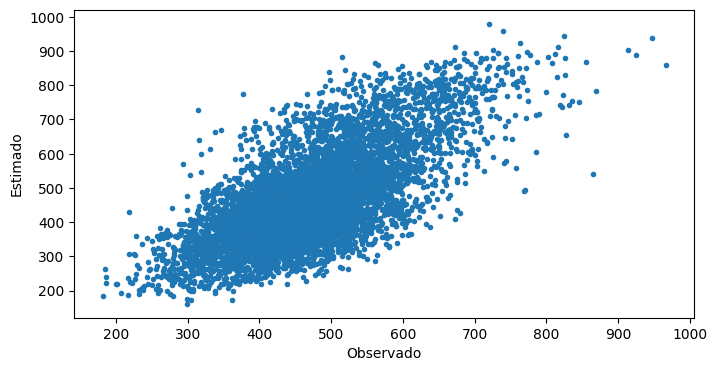

In [53]:
# Scatter plot do observado versus estimado
# Parece mais ou menos linear mas bem disperso

plt.figure(figsize=(8, 4))
plt.scatter(y_train_pred ,y_train, marker='.')
plt.xlabel("Observado")
plt.ylabel("Estimado");

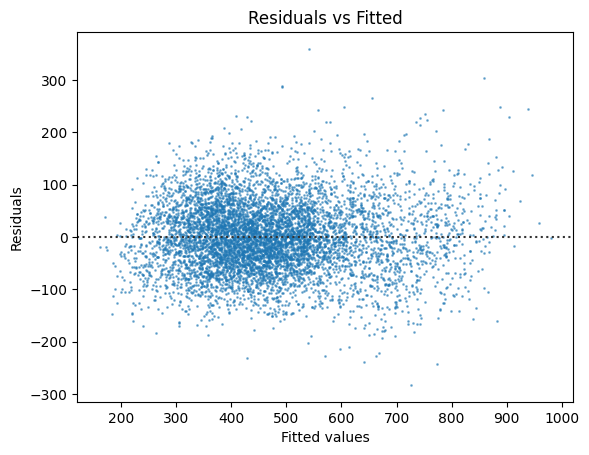

In [54]:
# Teste de Linearidade
# A distribuição de resíduos parece ser suficientemente aleatória

plot_lm_1 = plt.figure()
plot_lm_1 = sb.residplot(data=dataframe, x=dataframe.columns[-0], y=modelo_ajust_y,     
            scatter_kws={'alpha': 0.5, 's': 1},       
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted values') 
plt.ylabel('Residuals')
plt.show()   

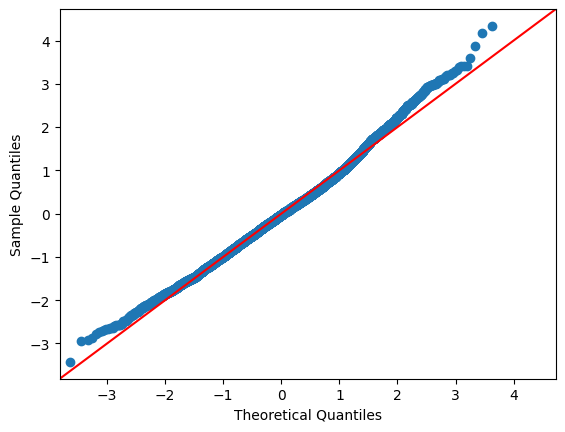

In [55]:
### Teste de Normalidade
### O gráfico de resíduos pode ser usado para verificar visualmente a suposição de normalidade.
### Sendo que para que se aceite que os resíduos estão normalmente distribuidos deve seguir aproximadamente uma linha reta.    
    
plot_lm_2  = sm.qqplot(modelo_norm_resid, line='45')
plt.show()


In [56]:
# Teste de shapiro
# P-value ficou quase zero

shapiro_test = stats.shapiro(modelo_norm_resid)
shapiro_test

d:\Programas\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7088.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9932807866752252), pvalue=np.float64(8.515718699970159e-18))

In [57]:
# Concluões 
# Alguns pontos de performance do modelo foram positivos (F-statistic significativo, P-values < 0.05, VIF < 4, ME ~ 0)
# Alguns pontos de performance poderiam ser considerados ruins ou não do ponto de vista de negócio (R² baixo, MAPE alto)
# Os gráficos de observado vs. estimado, resíduos e Gráfico Q-Q ficaram razoáveis
# O teste de Shapiro rejeitou a distribuição normal dos resíduos, mas pode ser algo aceitável

# Em algumas variáveis contínuas pareceu que os dados faziam uma leve curva
# Vou testar incluir termo quadrático e interação entre variáveis pra ver se melhora a performance
# Vou testar se deixei passar algum skew alto

## 2a Modelagem - StatsModels + constant e PolinomialFeatures

In [58]:
df

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log,SCORE_CREDITO
0,45,2.0,3,40,1,40.089665,3,1,1,False,False,False,False,0.000000,778.0
1,58,0.0,0,44,1,66.557645,3,1,0,True,False,False,True,0.000000,276.3
2,46,4.0,3,35,1,123.681821,6,1,1,True,True,False,False,0.000000,401.0
3,34,3.0,0,22,1,19.715934,6,1,0,False,False,False,True,0.000000,347.4
4,49,3.0,2,36,0,0.000000,3,1,2,False,False,False,False,6.082219,476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,3.0,0,45,1,100.128971,4,1,0,True,False,False,False,0.000000,470.0
10123,38,0.0,0,31,1,89.805996,6,1,1,True,False,False,True,0.000000,432.0
10124,49,2.0,3,43,1,19.799306,3,1,1,False,False,False,False,5.533389,406.0
10125,54,1.0,4,48,1,194.783176,4,1,1,True,False,False,False,0.000000,387.0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    10127 non-null  int64  
 1   escola                   10127 non-null  float64
 2   Qte_dependentes          10127 non-null  int64  
 3   tempo_ultimoservico      10127 non-null  int64  
 4   trabalha                 10127 non-null  int64  
 5   vl_salario_mil           10127 non-null  float64
 6   reg_moradia              10127 non-null  int64  
 7   Qte_cartoes              10127 non-null  int64  
 8   Qte_carros               10127 non-null  int64  
 9   sexo_M                   10127 non-null  bool   
 10  estado_civil_divorciado  10127 non-null  bool   
 11  estado_civil_na          10127 non-null  bool   
 12  estado_civil_solteiro    10127 non-null  bool   
 13  vl_imovel_em_mil_log     10127 non-null  float64
 14  SCORE_CREDITO         

In [60]:
# Dessa vez, ao invés de observar os histogramas, vou calcular o skew
# Variáveis com skew alto: "Qte_cartoes", "trabalha" (módulo > 1)
# Porém a variável trabalha é binária, não faz sentido passar log nela
# E a variável qte_cartões é quase categórica ordinal, não faz sentido passar log nela também

# Dessa forma, sem necessidade de transformações com log1p

col_numericas = df.select_dtypes(include=np.number).columns.to_list()
skew = df[col_numericas].skew().sort_values(ascending=False)
skew

Qte_cartoes             4.605743
SCORE_CREDITO           0.709218
vl_imovel_em_mil_log    0.674016
vl_salario_mil          0.659766
Qte_dependentes         0.506917
escola                  0.452347
Qte_carros              0.235710
idade                  -0.033605
tempo_ultimoservico    -0.060492
reg_moradia            -0.177534
trabalha               -2.907272
dtype: float64

In [61]:
df['trabalha'].unique()

array([1, 0])

In [62]:
df['Qte_cartoes'].unique()

array([1, 2, 3, 4])

In [63]:
# Rodando as separações de novo pra garantir que não mudei nada sem perceber

In [64]:
# Separação da variável target

X = df[df.columns[:-1]]
y = df['SCORE_CREDITO']

In [65]:
X

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
0,45,2.0,3,40,1,40.089665,3,1,1,False,False,False,False,0.000000
1,58,0.0,0,44,1,66.557645,3,1,0,True,False,False,True,0.000000
2,46,4.0,3,35,1,123.681821,6,1,1,True,True,False,False,0.000000
3,34,3.0,0,22,1,19.715934,6,1,0,False,False,False,True,0.000000
4,49,3.0,2,36,0,0.000000,3,1,2,False,False,False,False,6.082219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,3.0,0,45,1,100.128971,4,1,0,True,False,False,False,0.000000
10123,38,0.0,0,31,1,89.805996,6,1,1,True,False,False,True,0.000000
10124,49,2.0,3,43,1,19.799306,3,1,1,False,False,False,False,5.533389
10125,54,1.0,4,48,1,194.783176,4,1,1,True,False,False,False,0.000000


In [66]:
y

0        778.0
1        276.3
2        401.0
3        347.4
4        476.0
         ...  
10122    470.0
10123    432.0
10124    406.0
10125    387.0
10126    513.0
Name: SCORE_CREDITO, Length: 10127, dtype: float64

In [67]:
# Separação em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 12)

In [68]:
X_train

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
5653,50,1.0,2,38,1,101.142599,4,1,0,True,False,False,False,0.000000
3391,49,0.0,3,34,1,23.173473,3,1,1,False,False,False,False,6.122493
3818,44,1.0,3,32,1,65.966874,6,1,1,True,False,False,False,0.000000
8710,30,2.0,0,17,1,20.339844,3,1,1,False,False,False,True,0.000000
8034,53,2.0,2,35,1,74.658171,1,1,2,False,False,False,False,6.218600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,49,1.0,0,38,1,79.553644,1,1,1,False,False,False,False,6.833032
7409,40,0.0,3,28,1,27.735036,1,1,0,False,False,False,False,6.754604
3325,65,2.0,0,53,1,19.924990,3,1,0,True,False,False,False,5.697093
9606,57,3.0,0,49,1,23.175998,4,1,1,False,False,False,True,0.000000


In [69]:
y_train

5653    494.0
3391    477.0
3818    494.0
8710    414.0
8034    628.0
        ...  
3714    623.0
7409    458.0
3325    530.0
9606    536.4
5787    492.3
Name: SCORE_CREDITO, Length: 7088, dtype: float64

In [70]:
import statsmodels.api as sm
from scipy import stats

In [71]:
X_train

,idade,escola,Qte_dependentes,tempo_ultimoservico,trabalha,vl_salario_mil,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,vl_imovel_em_mil_log
5653,50,1.0,2,38,1,101.142599,4,1,0,True,False,False,False,0.000000
3391,49,0.0,3,34,1,23.173473,3,1,1,False,False,False,False,6.122493
3818,44,1.0,3,32,1,65.966874,6,1,1,True,False,False,False,0.000000
8710,30,2.0,0,17,1,20.339844,3,1,1,False,False,False,True,0.000000
8034,53,2.0,2,35,1,74.658171,1,1,2,False,False,False,False,6.218600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,49,1.0,0,38,1,79.553644,1,1,1,False,False,False,False,6.833032
7409,40,0.0,3,28,1,27.735036,1,1,0,False,False,False,False,6.754604
3325,65,2.0,0,53,1,19.924990,3,1,0,True,False,False,False,5.697093
9606,57,3.0,0,49,1,23.175998,4,1,1,False,False,False,True,0.000000


In [72]:
# Adicionando uma constante no X_train
# ALTERAÇÃO AQUI: Adicionando também termos quadráticos e interação - usando PolynomialFeatures

from sklearn.preprocessing import PolynomialFeatures

colunas_continuas = ['idade', 'tempo_ultimoservico', 'vl_salario_mil', 'vl_imovel_em_mil_log']
outras_colunas = [col for col in X_train.columns if col not in colunas_continuas]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

X_poly_array = poly.fit_transform(X_train[colunas_continuas])  ## DF original + novas colunas

X_outras = X_train[outras_colunas]


X_poly = pd.DataFrame(
    X_poly_array,
    columns=poly.get_feature_names_out(colunas_continuas),
    index=X_train.index 
)

X_final = pd.concat([X_train[outras_colunas], X_poly], axis=1)

X_final_const = sm.add_constant(X_final)    # Adiciona constante

X_final_const

,const,escola,Qte_dependentes,trabalha,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,...,idade^2,idade tempo_ultimoservico,idade vl_salario_mil,idade vl_imovel_em_mil_log,tempo_ultimoservico^2,tempo_ultimoservico vl_salario_mil,tempo_ultimoservico vl_imovel_em_mil_log,vl_salario_mil^2,vl_salario_mil vl_imovel_em_mil_log,vl_imovel_em_mil_log^2
5653,1.0,1.0,2,1,4,1,0,True,False,False,...,2500.0,1900.0,5057.129959,0.000000,1444.0,3843.418769,0.000000,10229.825370,0.000000,0.000000
3391,1.0,0.0,3,1,3,1,1,False,False,False,...,2401.0,1666.0,1135.500194,300.002148,1156.0,787.898094,208.164756,537.009867,141.879424,37.484918
3818,1.0,1.0,3,1,6,1,1,True,False,False,...,1936.0,1408.0,2902.542458,0.000000,1024.0,2110.939970,0.000000,4351.628472,0.000000,0.000000
8710,1.0,2.0,0,1,3,1,1,False,False,False,...,900.0,510.0,610.195334,0.000000,289.0,345.777356,0.000000,413.709273,0.000000,0.000000
8034,1.0,2.0,2,1,1,1,2,False,False,False,...,2809.0,1855.0,3956.883043,329.585806,1225.0,2613.035972,217.651004,5573.842440,464.269309,38.670987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,1.0,1.0,0,1,1,1,1,False,False,False,...,2401.0,1862.0,3898.128563,334.818555,1444.0,3023.038477,259.655206,6328.782297,543.592575,46.690323
7409,1.0,0.0,3,1,1,1,0,False,False,False,...,1600.0,1120.0,1109.401451,270.184164,784.0,776.581016,189.128915,769.232238,187.339190,45.624677
3325,1.0,2.0,0,1,3,1,0,True,False,False,...,4225.0,3445.0,1295.124332,370.311077,2809.0,1056.024456,301.945955,397.005216,113.514529,32.456874
9606,1.0,3.0,0,1,4,1,1,False,False,False,...,3249.0,2793.0,1321.031884,0.000000,2401.0,1135.623901,0.000000,537.126882,0.000000,0.000000


In [73]:
X_final_const.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7088 entries, 5653 to 5787
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   const                                     7088 non-null   float64
 1   escola                                    7088 non-null   float64
 2   Qte_dependentes                           7088 non-null   int64  
 3   trabalha                                  7088 non-null   int64  
 4   reg_moradia                               7088 non-null   int64  
 5   Qte_cartoes                               7088 non-null   int64  
 6   Qte_carros                                7088 non-null   int64  
 7   sexo_M                                    7088 non-null   bool   
 8   estado_civil_divorciado                   7088 non-null   bool   
 9   estado_civil_na                           7088 non-null   bool   
 10  estado_civil_solteiro                 

In [74]:
X_final_const

,const,escola,Qte_dependentes,trabalha,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,...,idade^2,idade tempo_ultimoservico,idade vl_salario_mil,idade vl_imovel_em_mil_log,tempo_ultimoservico^2,tempo_ultimoservico vl_salario_mil,tempo_ultimoservico vl_imovel_em_mil_log,vl_salario_mil^2,vl_salario_mil vl_imovel_em_mil_log,vl_imovel_em_mil_log^2
5653,1.0,1.0,2,1,4,1,0,True,False,False,...,2500.0,1900.0,5057.129959,0.000000,1444.0,3843.418769,0.000000,10229.825370,0.000000,0.000000
3391,1.0,0.0,3,1,3,1,1,False,False,False,...,2401.0,1666.0,1135.500194,300.002148,1156.0,787.898094,208.164756,537.009867,141.879424,37.484918
3818,1.0,1.0,3,1,6,1,1,True,False,False,...,1936.0,1408.0,2902.542458,0.000000,1024.0,2110.939970,0.000000,4351.628472,0.000000,0.000000
8710,1.0,2.0,0,1,3,1,1,False,False,False,...,900.0,510.0,610.195334,0.000000,289.0,345.777356,0.000000,413.709273,0.000000,0.000000
8034,1.0,2.0,2,1,1,1,2,False,False,False,...,2809.0,1855.0,3956.883043,329.585806,1225.0,2613.035972,217.651004,5573.842440,464.269309,38.670987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,1.0,1.0,0,1,1,1,1,False,False,False,...,2401.0,1862.0,3898.128563,334.818555,1444.0,3023.038477,259.655206,6328.782297,543.592575,46.690323
7409,1.0,0.0,3,1,1,1,0,False,False,False,...,1600.0,1120.0,1109.401451,270.184164,784.0,776.581016,189.128915,769.232238,187.339190,45.624677
3325,1.0,2.0,0,1,3,1,0,True,False,False,...,4225.0,3445.0,1295.124332,370.311077,2809.0,1056.024456,301.945955,397.005216,113.514529,32.456874
9606,1.0,3.0,0,1,4,1,1,False,False,False,...,3249.0,2793.0,1321.031884,0.000000,2401.0,1135.623901,0.000000,537.126882,0.000000,0.000000


In [75]:
y_train

5653    494.0
3391    477.0
3818    494.0
8710    414.0
8034    628.0
        ...  
3714    623.0
7409    458.0
3325    530.0
9606    536.4
5787    492.3
Name: SCORE_CREDITO, Length: 7088, dtype: float64

In [76]:
# Tive problemas de datatype na conversão pra numpy pro modelo
# Então vou forçar todas pra float64

X_final_const = X_final_const.astype(float)

In [77]:
model_OLS = sm.OLS(y_train, X_final_const).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     580.7
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:32:10   Log-Likelihood:                -40894.
No. Observations:                7088   AIC:                         8.184e+04
Df Residuals:                    7063   BIC:                         8.201e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [78]:
# Interpretação dos novos resultados:

# R²: Modelo passou de ajustar 49% para 66% dos dados, uma melhora significativa!!
# F-statistic: Deu ainda mais alto (495.2 -> 580.7), modelo parece altamente significativo
# Nenhum coeficiente ficou modularmente muito alto, não parece haver multicolinearidade

# Das variáveis:
# Qte_dependentes, que antes tinha um p-value 0.039, agora tem 0.075, passando do limiar de 0.05
# idade^2 - p-value 0.198

# Sendo assim, vou remover Qte_dependentes e idade^2 e rerodar

In [79]:
X_final_const = X_final_const.drop(columns=['Qte_dependentes', 'idade^2'])
X_final_const

,const,escola,trabalha,reg_moradia,Qte_cartoes,Qte_carros,sexo_M,estado_civil_divorciado,estado_civil_na,estado_civil_solteiro,...,vl_imovel_em_mil_log,idade tempo_ultimoservico,idade vl_salario_mil,idade vl_imovel_em_mil_log,tempo_ultimoservico^2,tempo_ultimoservico vl_salario_mil,tempo_ultimoservico vl_imovel_em_mil_log,vl_salario_mil^2,vl_salario_mil vl_imovel_em_mil_log,vl_imovel_em_mil_log^2
5653,1.0,1.0,1.0,4.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.000000,1900.0,5057.129959,0.000000,1444.0,3843.418769,0.000000,10229.825370,0.000000,0.000000
3391,1.0,0.0,1.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,...,6.122493,1666.0,1135.500194,300.002148,1156.0,787.898094,208.164756,537.009867,141.879424,37.484918
3818,1.0,1.0,1.0,6.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.000000,1408.0,2902.542458,0.000000,1024.0,2110.939970,0.000000,4351.628472,0.000000,0.000000
8710,1.0,2.0,1.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.000000,510.0,610.195334,0.000000,289.0,345.777356,0.000000,413.709273,0.000000,0.000000
8034,1.0,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,...,6.218600,1855.0,3956.883043,329.585806,1225.0,2613.035972,217.651004,5573.842440,464.269309,38.670987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,6.833032,1862.0,3898.128563,334.818555,1444.0,3023.038477,259.655206,6328.782297,543.592575,46.690323
7409,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.754604,1120.0,1109.401451,270.184164,784.0,776.581016,189.128915,769.232238,187.339190,45.624677
3325,1.0,2.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,...,5.697093,3445.0,1295.124332,370.311077,2809.0,1056.024456,301.945955,397.005216,113.514529,32.456874
9606,1.0,3.0,1.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.000000,2793.0,1321.031884,0.000000,2401.0,1135.623901,0.000000,537.126882,0.000000,0.000000


In [80]:
# Rerodando
model_OLS = sm.OLS(y_train, X_final_const).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     633.1
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:32:11   Log-Likelihood:                -40896.
No. Observations:                7088   AIC:                         8.184e+04
Df Residuals:                    7065   BIC:                         8.200e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [81]:
# "idade vl_imovel_em_mil_log" agora passou também, vou rodar sem pra testar

# Resultados do modelo se mantiveram (R² se manteve, F-statistic aumentou)

X_final_const = X_final_const.drop(columns=['idade vl_imovel_em_mil_log'])

model_OLS = sm.OLS(y_train, X_final_const).fit()

print(model_OLS.summary())

                            OLS Regression Results                            
Dep. Variable:          SCORE_CREDITO   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     662.8
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:32:11   Log-Likelihood:                -40898.
No. Observations:                7088   AIC:                         8.184e+04
Df Residuals:                    7066   BIC:                         8.199e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [82]:
# Sobre a nota [2] do resultado: Já é esperada multicolinearidade dos termos novos criados
# Sendo assim, confirmando multicolinearidade com VIF só por curiosidade

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcula VIF para cada coluna
vif = pd.DataFrame()
vif["variável"] = X_final_const.columns
vif["VIF"] = [variance_inflation_factor(X_final_const.values, i) for i in range(X_final_const.shape[1])]

print(vif)

                                    variável         VIF
0                                      const  728.230840
1                                     escola    1.070626
2                                   trabalha    1.557332
3                                reg_moradia    3.147290
4                                Qte_cartoes    1.049121
5                                 Qte_carros    1.072490
6                                     sexo_M    2.507281
7                    estado_civil_divorciado    1.077436
8                            estado_civil_na    1.078713
9                      estado_civil_solteiro    1.355434
10                                     idade   74.676020
11                       tempo_ultimoservico   35.658884
12                            vl_salario_mil   56.336647
13                      vl_imovel_em_mil_log   80.688395
14                 idade tempo_ultimoservico  385.425421
15                      idade vl_salario_mil  107.258909
16                     tempo_ul

In [83]:
# Calculando medidas de performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Aplicando 
y_train_pred = model_OLS.predict(X_final_const)

# Avaliando
# Medidas de erro na amostra treino 

me1   = round((y_train-y_train_pred).mean(),2)
print('Erro Médio (Mean error-ME):', me1)
mae1  = round((mean_absolute_error(y_train, y_train_pred)),2)
print('Erro Médio Absoluto (Mean Absolut Error-MAE):', mae1) 
mse1  =round( (mean_squared_error(y_train, y_train_pred)),2)
print('Erro Quadrático Médio (Mean Squared Error-MSE)::', mse1) 
rmse1  = round((np.sqrt(mean_squared_error(y_train, y_train_pred))),2)
print('Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE):', rmse1) 
mpe1  = round(((y_train - y_train_pred)/y_train).mean(),2)
print('Erro Percentual Médio (Mean Percent Error-MPE):', mpe1) 
mape1  =  round((mae1/y_train).mean(),2) 
print('Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE):', mape1) 

Erro Médio (Mean error-ME): 0.0
Erro Médio Absoluto (Mean Absolut Error-MAE): 58.81
Erro Quadrático Médio (Mean Squared Error-MSE):: 6016.32
Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE): 77.56
Erro Percentual Médio (Mean Percent Error-MPE): -0.03
Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE): 0.14


In [84]:
# Considerações:
# Erro médio continua próximo de zero, o que é bom, o modelo não tende a superestimar ou subestimar
# MAPE foi de 0.17 pra 0.14 - pode ser considerado ruim do ponto de vista de negócio ou não

In [85]:
# Construção de diagnóstico para os gráficos

modelo_ajust_y = model_OLS.fittedvalues # Valores do modelo ajustados

modelo_residuos = model_OLS.resid # Residuos

modelo_norm_resid = model_OLS.get_influence().resid_studentized_internal # Residuos normalizados

modelo_norm_resid_abs = np.sqrt(np.abs(modelo_norm_resid)) # Quadrados dos residuos normalizados

modelo_outliers = model_OLS.get_influence().hat_matrix_diag # Outliers

distancia_cook = model_OLS.get_influence().cooks_distance[0] # Distancia de Cook


In [86]:
# Observado versus estimado pelo modelo
dataframe = pd.concat([y_train, modelo_ajust_y], axis=1)
dataframe

,SCORE_CREDITO,0
5653,494.0,450.068912
3391,477.0,476.300202
3818,494.0,447.204160
8710,414.0,357.518098
8034,628.0,587.762239
...,...,...
3714,623.0,646.892395
7409,458.0,502.586128
3325,530.0,416.394160
9606,536.4,523.361656


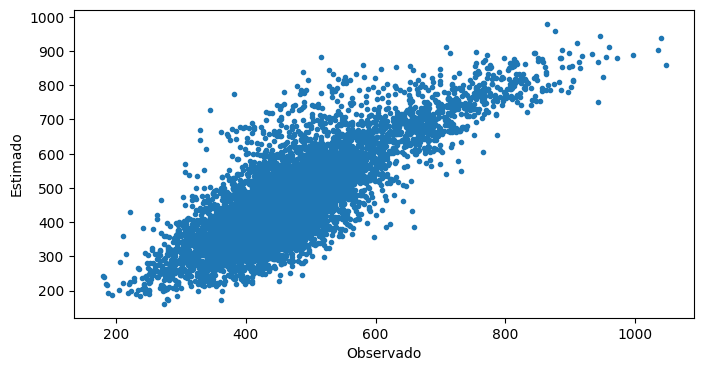

In [87]:
# Scatter plot do observado versus estimado
# Houve uma boa "afinada" na linha observado vs estimado
# Representa a melhora do R² 

plt.figure(figsize=(8, 4))
plt.scatter(y_train_pred ,y_train, marker='.')
plt.xlabel("Observado")
plt.ylabel("Estimado");

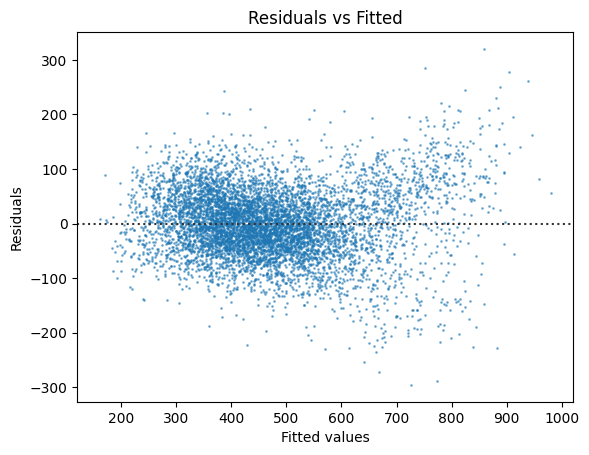

In [88]:
# Teste de Linearidade
# A distribuição de resíduos parece ser suficientemente aleatória

plot_lm_1 = plt.figure()
plot_lm_1 = sb.residplot(data=dataframe, x=dataframe.columns[-0], y=modelo_ajust_y,     
            scatter_kws={'alpha': 0.5, 's': 1},       
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted values') 
plt.ylabel('Residuals')
plt.show()   

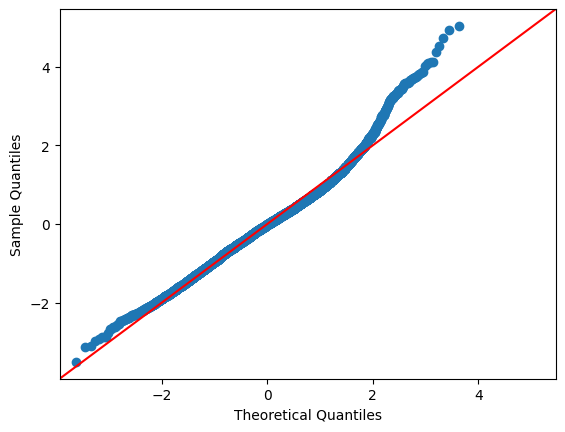

In [89]:
### Teste de Normalidade
### O gráfico de resíduos pode ser usado para verificar visualmente a suposição de normalidade.
### Sendo que para que se aceite que os resíduos estão normalmente distribuidos deve seguir aproximadamente uma linha reta.    
    
plot_lm_2  = sm.qqplot(modelo_norm_resid, line='45')
plt.show()

In [90]:
# Teste de shapiro
# P-value ficou quase zero, rejeita a hipótese nula de normalidade

shapiro_test = stats.shapiro(modelo_norm_resid)
shapiro_test

d:\Programas\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7088.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9815845453276457), pvalue=np.float64(2.395244206371092e-29))

In [91]:
# Concluões finais: 

# Novo modelo melhorou muito em performance, com F-statistic mais alto e R² subindo de 0.49 para 0.66 
# MAPE melhorou de 0.17 para 0.14, ME se manteve ~0
# Os plots Gráfico Q-Q e Resíduos se mostraram positivos, tendo em vista a performance alcançada

# Sendo assim, o modelo pode ser considerado satisfatório para o problema proposto

# Mesmo assim, é importante pensar em alguns pontos antes de sua implementação:
## - Existem variáveis que não foram coletadas e poderiam melhorar o modelo?
## - O modelo pode ser melhorado com outras técnicas de regressão, como Random Forest, XGXGBoost e LightGBM?
## - Qual o método de scoring atual que forneceu os dados usados aqui, e quais variáveis ele usa, para comparar a performance?